# Employee Attrition Analysis — Executive Summary
 
- This notebook summarizes the main findings of the **Employee Attrition Analysis** project.

- The objective of this project is to understand which **employee characteristics** are associated with *a*ttrition** and to compare **logistic regression models** that can support decision-making.

- This executive summary **does not replace** the technical notebooks. Instead, it consolidates the main results from data preparation, exploratory analysis, modeling, and final model selection.

In [162]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


TABLES_DIR = Path("../../outputs/tables")

target_distribution_percent = pd.read_csv(
    TABLES_DIR / "target_distribution_percent.csv"
)

categorical_rates = pd.read_csv(
    TABLES_DIR / "categorical_attrition_rates.csv"
)

cramers_v = pd.read_csv(
    TABLES_DIR / "cramers_V_attrition_results.csv"
)

quantitative_stats = pd.read_csv(
    TABLES_DIR / "quantitative_stats_by_attrition.csv"
)

quantitative_corr = pd.read_csv(
    TABLES_DIR / "quantitative_correlation_attrition.csv"
)

mixed_associations = pd.read_csv(
    TABLES_DIR / "mixed_association_results.csv"
)

mixed_vif = pd.read_csv(
    TABLES_DIR / "mixed_vif_results.csv"
)

final_summary = pd.read_csv(
    TABLES_DIR / "final_summary.csv"
)

final_gap_analysis = pd.read_csv(
    TABLES_DIR / "final_gap_analysis.csv"
)

final_test_results = pd.read_csv(
    TABLES_DIR / "final_test_results.csv"
)

model_2_odds = pd.read_csv(
    TABLES_DIR / "model_2_odds_ratios.csv"
)

model_3_odds = pd.read_csv(
    TABLES_DIR / "model_3_odds_ratios.csv"
)

## 1. Dataset Overview

The dataset contains employee-level information related to personal characteristics, job role, compensation, satisfaction, work conditions, and attrition status.

The target variable is `Attrition`, later encoded as `AttritionFlag`, where:
- `1` represents employees who left the company;
- `0` represents employees who stayed.

The dataset is imbalanced, with attrition representing a minority class. Because of this, the final evaluation considers not only accuracy, but also recall, precision, F1-score, AUC, and confusion matrices.

In [163]:
target_distribution_percent

,Attrition,proportion
0,No,0.838776
1,Yes,0.161224


## 2. Main Categorical Findings

The categorical analysis shows that attrition is not evenly distributed across employee groups.

Higher attrition rates appear especially among employees in early-career stages, lower job levels, shorter tenure groups, lower income groups, employees with overtime, low job involvement, low satisfaction, poor work-life balance, and no stock options.

In [164]:
categorical_rates

,variable,category,total_employees,attrition_count,attrition_rate
0,BusinessTravel,Travel_Frequently,277,69,24.91
1,BusinessTravel,Travel_Rarely,1043,156,14.96
2,BusinessTravel,Non-Travel,150,12,8.00
3,Department,Sales,446,92,20.63
4,Department,Human Resources,63,12,19.05
...,...,...,...,...,...
90,RelationshipSatisfactionLevel,Very High,432,64,14.81
91,WorkLifeBalanceLevel,Bad,80,25,31.25
92,WorkLifeBalanceLevel,Best,153,27,17.65
93,WorkLifeBalanceLevel,Good,344,58,16.86


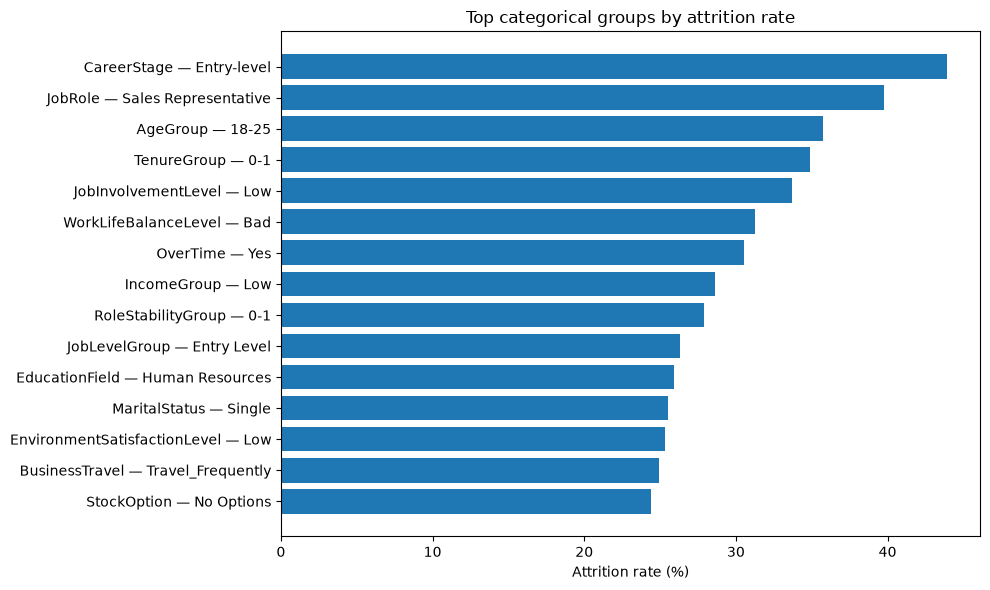

In [165]:
top_categorical_view = (
    categorical_rates
    .sort_values("attrition_rate", ascending=False)
    .head(15)
    .copy()
)


top_categorical_view["Variable_Category"] = (
    top_categorical_view["variable"].astype(str)
    + " — "
    + top_categorical_view["category"].astype(str)
)


plt.figure(figsize=(10, 6))

plt.barh(
    top_categorical_view["Variable_Category"],
    top_categorical_view["attrition_rate"]
)

plt.xlabel("Attrition rate (%)")
plt.title("Top categorical groups by attrition rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Association Between Categorical Variables and Attrition

The Chi-square and Cramer's V results indicate that several categorical variables have a statistically significant association with attrition.

The strongest associations are related to career stage, overtime, job role, tenure group, job level, income group, stock options, and age group.

Most associations are moderate or weak, which suggests that attrition is a multifactorial phenomenon rather than the result of one isolated factor.

In [166]:
cramers_v.sort_values("Cramers_V", ascending=False).reset_index(drop=True)


,Primary_Variable,Secondary_Variable,Cramers_V,p_value,Significativo,Association
0,Attrition,CareerStage,0.245,0.0000,Sim,Moderada
1,Attrition,OverTime,0.244,0.0000,Sim,Moderada
2,Attrition,JobRole,0.242,0.0000,Sim,Moderada
3,Attrition,TenureGroup,0.227,0.0000,Sim,Moderada
4,Attrition,JobLevelGroup,0.222,0.0000,Sim,Moderada
5,Attrition,IncomeGroup,0.209,0.0000,Sim,Moderada
6,Attrition,StockOption,0.203,0.0000,Sim,Moderada
7,Attrition,AgeGroup,0.201,0.0000,Sim,Moderada
8,Attrition,RoleStabilityGroup,0.183,0.0000,Sim,Fraca
9,Attrition,MaritalStatus,0.177,0.0000,Sim,Fraca


## 4. Quantitative Findings

The quantitative analysis shows that employees who left the company tend to be younger, have lower monthly income, fewer total working years, fewer years at the company, fewer years in the current role, and fewer years with their current manager.

Employees with attrition also tend to live farther from work.

However, the correlations between individual quantitative variables and attrition are weak, which means that quantitative variables should be interpreted together with categorical and organizational factors.

In [167]:
quantitative_stats.reset_index(drop=True)

,Variable,AttritionFlag,Count,Mean,Median,Std,Min,Q1,Q3,Max
0,Age,0,1233,37.561,36.0,8.888,18,31.0,43.0,60
1,Age,1,237,33.608,32.0,9.689,18,28.0,39.0,58
2,DailyRate,0,1233,812.504,817.0,403.208,102,477.0,1176.0,1499
3,DailyRate,1,237,750.363,699.0,401.900,103,408.0,1092.0,1496
4,DistanceFromHome,0,1233,8.916,7.0,8.013,1,2.0,13.0,29
5,DistanceFromHome,1,237,10.633,9.0,8.453,1,3.0,17.0,29
6,HourlyRate,0,1233,65.952,66.0,20.381,30,48.0,83.0,100
7,HourlyRate,1,237,65.574,66.0,20.100,31,50.0,84.0,100
8,MonthlyIncome,0,1233,6832.740,5204.0,4818.208,1051,3211.0,8834.0,19999
9,MonthlyIncome,1,237,4787.093,3202.0,3640.210,1009,2373.0,5916.0,19859


In [168]:
quantitative_means = (
    quantitative_selected
    .pivot(index="Variable", columns="AttritionFlag", values="Mean")
)

quantitative_means.columns = ["No Attrition", "Attrition"]

quantitative_means.round(2)

,No Attrition,Attrition
Variable,,
Age,37.56,33.61
DistanceFromHome,8.92,10.63
MonthlyIncome,6832.74,4787.09
TotalWorkingYears,11.86,8.24
YearsAtCompany,7.37,5.13
YearsInCurrentRole,4.48,2.90
YearsWithCurrManager,4.37,2.85


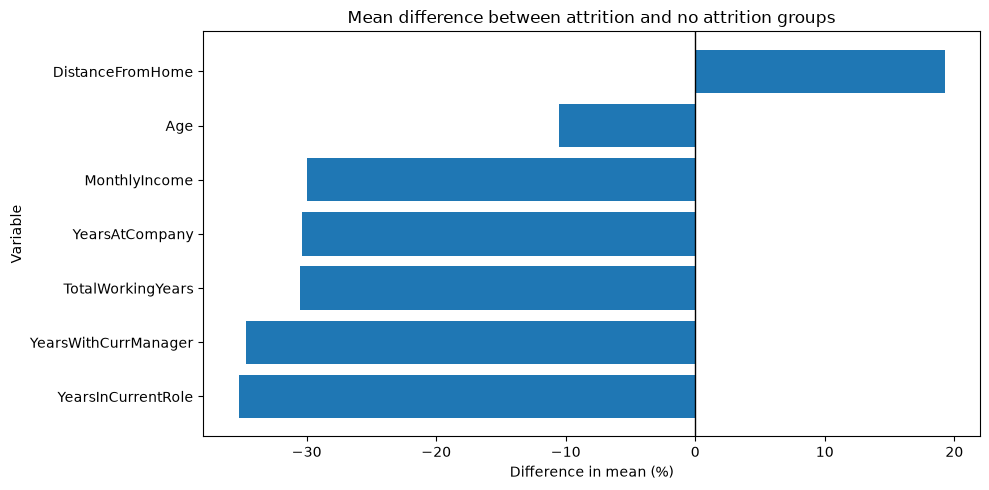

In [169]:
quantitative_diff = quantitative_means.copy()

quantitative_diff["Difference"] = (
    quantitative_diff["Attrition"] - quantitative_diff["No Attrition"]
)

quantitative_diff["Difference_%"] = (
    quantitative_diff["Difference"] / quantitative_diff["No Attrition"] * 100
)

quantitative_diff = quantitative_diff.sort_values("Difference_%")

plt.figure(figsize=(10, 5))

plt.barh(
    quantitative_diff.index,
    quantitative_diff["Difference_%"]
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Difference in mean (%)")
plt.ylabel("Variable")
plt.title("Mean difference between attrition and no attrition groups")
plt.tight_layout()
plt.show()

## 5. Quantitative Correlation With Attrition

The strongest quantitative correlations with attrition are negative and related to experience, income, tenure, and age.

This suggests that employees with more professional experience, higher income, longer tenure, and more time in their current role tend to have lower attrition risk.

`DistanceFromHome` is positively associated with attrition, suggesting that longer commuting distance may increase the probability of leaving.

In [170]:
quantitative_corr.sort_values("Abs_Correlation", ascending=False).reset_index(drop=True)

,Feature,Correlation,Abs_Correlation,p_value,Significativo,Association
0,TotalWorkingYears,-0.199,0.199,0.0000,Sim,Fraca
1,MonthlyIncome,-0.198,0.198,0.0000,Sim,Fraca
2,YearsAtCompany,-0.190,0.190,0.0000,Sim,Fraca
3,YearsInCurrentRole,-0.181,0.181,0.0000,Sim,Fraca
4,YearsWithCurrManager,-0.175,0.175,0.0000,Sim,Fraca
5,Age,-0.171,0.171,0.0000,Sim,Fraca
6,DistanceFromHome,0.079,0.079,0.0024,Sim,Fraca
7,DailyRate,-0.057,0.057,0.0289,Sim,Fraca
8,YearsSinceLastPromotion,-0.053,0.053,0.0411,Sim,Fraca
9,TrainingTimesLastYear,-0.052,0.052,0.0473,Sim,Fraca


## 6. Mixed Analysis and Multicollinearity

The mixed analysis confirms that many grouped categorical variables are strongly associated with their original numerical variables.

For example, income group is strongly related to monthly income, age group is strongly related to age, and distance group is strongly related to distance from home.

This validates the grouped variables, but also shows that broad models can contain redundant information. For this reason, the integrated multidimensional model is treated as a control model rather than the final interpretive model.

In [171]:
mixed_associations.sort_values("Eta_Squared", ascending=False).head(20).reset_index(drop=True)

,Categorical_Variable,Quantitative_Variable,Eta_Squared,Kruskal_Statistic,p_value,Significativo,Força
0,DistanceGroup,DistanceFromHome,0.947,1322.965,0.0,Sim,Forte
1,JobLevelGroup,MonthlyIncome,0.925,1245.176,0.0,Sim,Forte
2,AgeGroup,Age,0.908,1314.041,0.0,Sim,Forte
3,CareerStage,TotalWorkingYears,0.898,1345.374,0.0,Sim,Forte
4,PromotionDelayGroup,YearsSinceLastPromotion,0.878,1418.465,0.0,Sim,Forte
5,RoleStabilityGroup,YearsInCurrentRole,0.877,1394.262,0.0,Sim,Forte
6,IncomeGroup,MonthlyIncome,0.877,1355.971,0.0,Sim,Forte
7,TenureGroup,YearsAtCompany,0.818,1404.813,0.0,Sim,Forte
8,JobRole,MonthlyIncome,0.816,1073.410,0.0,Sim,Forte
9,TenureGroup,YearsInCurrentRole,0.702,1069.682,0.0,Sim,Forte


### Mixed VIF Results

The VIF analysis shows that some mixed predictors have high multicollinearity, especially variables related to income, job level, department, job role, age, tenure, and distance.

This supports the decision to avoid selecting the most complex model as the final interpretive model.

In [172]:
mixed_vif[mixed_vif["VIF"]>=5].sort_values("VIF", ascending=False).reset_index(drop=True)

,Feature,VIF,Multicollinearity
0,MonthlyIncome,47.690,Forte
1,Department_Sales,45.596,Forte
2,Department_Research & Development,45.582,Forte
3,EducationField_Life Sciences,24.806,Forte
4,EducationField_Medical,22.316,Forte
5,DistanceGroup_21-30,19.921,Forte
6,DistanceFromHome,19.827,Forte
7,TenureGroup_10+,18.490,Forte
8,CareerStage_Late career,17.932,Forte
9,AgeGroup_46-55,16.829,Forte


## 7. Final Model Selection Strategy

The final model selection considers two possible decision strategies:

1. **Balanced and interpretable strategy**  
Uses the model with the best balance between performance, stability, interpretability, and business relevance.

2. **Recall-oriented strategy**  
Uses the model that reduces false negatives and identifies more employees who actually left, even if it increases false positives.

The integrated multidimensional model is kept only as a control model. It provides a benchmark for predictive performance, but it is not selected as the final model because it is more complex and more affected by multicollinearity.

In [173]:
control_model = final_summary[
    (final_summary["Variable_Set"] == "Modelo 8 — Integrado Multidimensional")
    & (final_summary["Model"] == "Logistic Regression")
].copy()

main_model = final_summary[
    (final_summary["Variable_Set"] == "Modelo 2 — Nível Hierárquico e Benefícios")
    & (final_summary["Model"] == "Logistic Regression Balanced")
].copy()

recall_model = final_summary[
    (final_summary["Variable_Set"] == "Modelo 3 — Faixa Salarial")
    & (final_summary["Model"] == "Logistic Regression Balanced")
].copy()

control_model["Decision_Role"] = "Control benchmark"
main_model["Decision_Role"] = "Main balanced and interpretable model"
recall_model["Decision_Role"] = "Recall-oriented alternative"

executive_models = pd.concat(
    [
        control_model,
        main_model,
        recall_model,
    ],
    ignore_index=True,
)

executive_models = executive_models[
    [
        "Decision_Role",
        "Variable_Set",
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC",
        "Best_Score",
        "Train_F1_Mean",
        "CV_F1_Mean",
        "F1_Gap",
        "Train_Recall_Mean",
        "CV_Recall_Mean",
        "Recall_Gap",
        "Gap_Diagnosis",
    ]
]

executive_models

,Decision_Role,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,Best_Score,Train_F1_Mean,CV_F1_Mean,F1_Gap,Train_Recall_Mean,CV_Recall_Mean,Recall_Gap,Gap_Diagnosis
0,Control benchmark,Modelo 8 — Integrado Multidimensional,Logistic Regression,0.38,0.864,0.575,0.592,0.583,0.814,0.542,0.606,0.526,0.080,0.483,0.422,0.062,Moderate gap
1,Main balanced and interpretable model,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.71,0.864,0.582,0.549,0.565,0.830,0.484,0.515,0.478,0.037,0.780,0.716,0.064,Stable generalization
2,Recall-oriented alternative,Modelo 3 — Faixa Salarial,Logistic Regression Balanced,0.58,0.810,0.437,0.634,0.517,0.797,0.442,0.475,0.440,0.035,0.731,0.679,0.052,Stable generalization


## 8. Final Model Performance Comparison

The control model achieved strong predictive performance, but it was not selected because its purpose is only to act as a benchmark.

The main selected model is `Modelo 2 — Nível Hierárquico e Benefícios` with balanced logistic regression and a threshold of 0.71. This model offers the best balance between predictive performance, interpretability, AUC, and stable generalization.

The recall-oriented alternative is `Modelo 3 — Faixa Salarial` with balanced logistic regression and a threshold of 0.58. This model identifies more employees who actually left, reducing false negatives, but it also increases false positives and reduces precision.

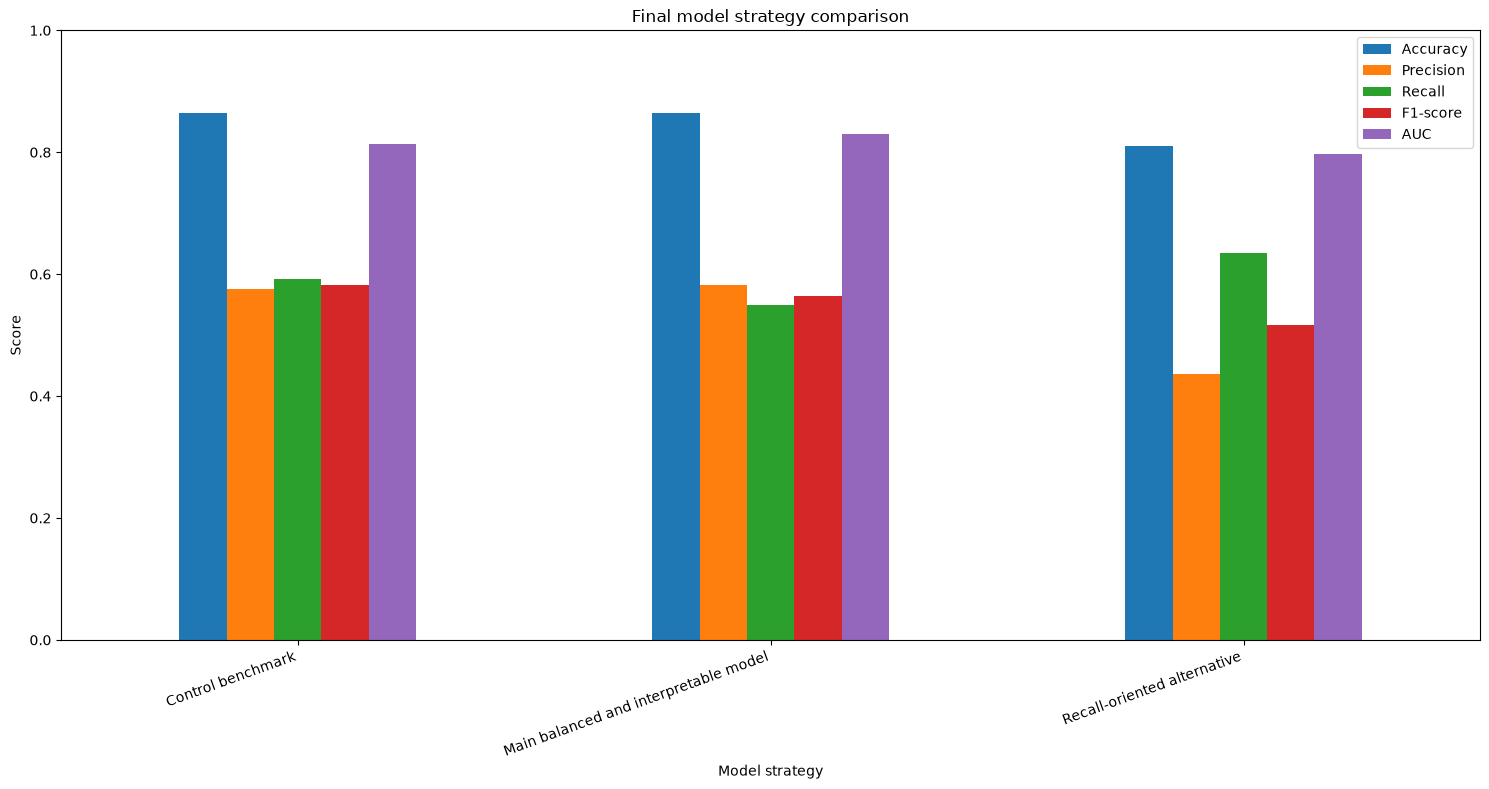

In [174]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]

executive_models.set_index("Decision_Role")[metrics].plot(
    kind="bar",
    figsize=(15, 8),
)

plt.title("Final model strategy comparison")
plt.ylabel("Score")
plt.xlabel("Model strategy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Confusion Matrix Comparison

In an attrition context, false negatives are especially important.

A false negative means that the model predicts that an employee will stay, but the employee actually leaves. This can be costly because the organization may lose the opportunity to act preventively.

The balanced model has fewer false positives and better overall balance. The recall-oriented model reduces false negatives, but increases false positives.

In [175]:
confusion_comparison = pd.DataFrame(
    {
        "Decision_Role": [
            "Main balanced and interpretable model",
            "Recall-oriented alternative",
        ],
        "Variable_Set": [
            "Modelo 2 — Nível Hierárquico e Benefícios",
            "Modelo 3 — Faixa Salarial",
        ],
        "Model": [
            "Logistic Regression Balanced",
            "Logistic Regression Balanced",
        ],
        "Threshold": [
            0.71,
            0.58,
        ],
        "True Negatives": [
            342,
            312,
        ],
        "False Positives": [
            28,
            58,
        ],
        "False Negatives": [
            32,
            26,
        ],
        "True Positives": [
            39,
            45,
        ],
    }
)

confusion_comparison

,Decision_Role,Variable_Set,Model,Threshold,True Negatives,False Positives,False Negatives,True Positives
0,Main balanced and interpretable model,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.71,342,28,32,39
1,Recall-oriented alternative,Modelo 3 — Faixa Salarial,Logistic Regression Balanced,0.58,312,58,26,45


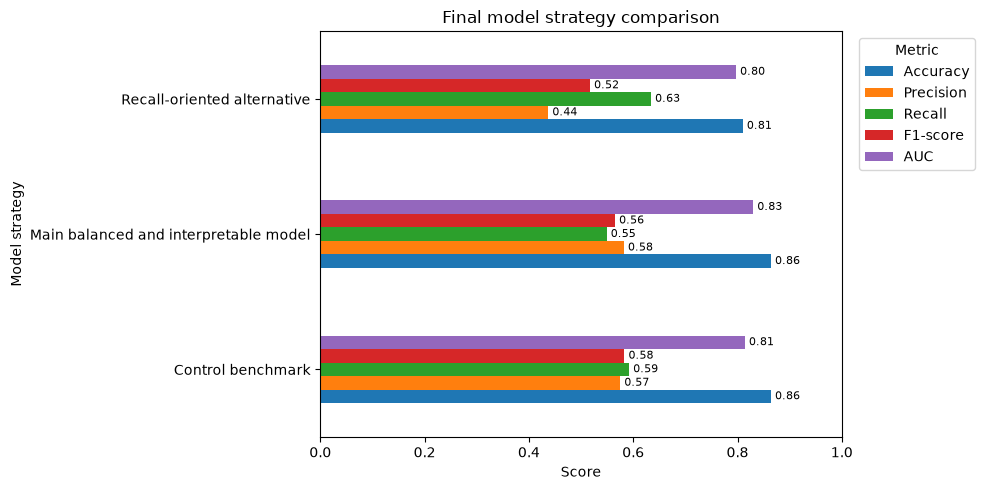

In [176]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]

plot_data = executive_models.set_index("Decision_Role")[metrics]

ax = plot_data.plot(
    kind="barh",
    figsize=(10, 5),
    xlim=(0, 1)
)

plt.title("Final model strategy comparison")
plt.xlabel("Score")
plt.ylabel("Model strategy")
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=3)

plt.tight_layout()
plt.show()

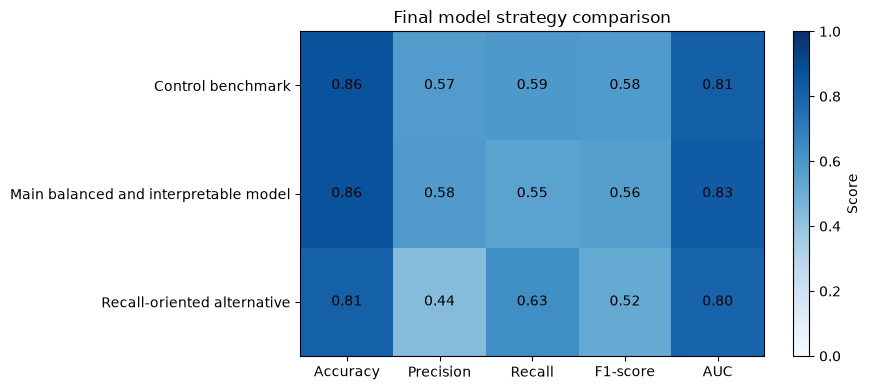

In [177]:
plot_data = executive_models.set_index("Decision_Role")[metrics]

fig, ax = plt.subplots(figsize=(9, 4))

im = ax.imshow(plot_data.values, aspect="auto", vmin=0, vmax=1, cmap="Blues")

ax.set_xticks(range(len(plot_data.columns)))
ax.set_xticklabels(plot_data.columns)

ax.set_yticks(range(len(plot_data.index)))
ax.set_yticklabels(plot_data.index)

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        ax.text(
            j,
            i,
            f"{plot_data.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Final model strategy comparison")
plt.colorbar(im, ax=ax, label="Score")
plt.tight_layout()
plt.show()

## 10. Main Balanced and Interpretable Model

The main selected model is:

**Modelo 2 — Nível Hierárquico e Benefícios**  
**Estimator:** Logistic Regression Balanced  
**Threshold:** 0.71

This model was selected because it provides the best balance between predictive performance, interpretability, AUC, and stable generalization.

The strongest risk factors include frequent business travel, overtime, low job involvement, low environment satisfaction, no stock options, low job satisfaction, and greater distance from home.

The strongest protective factors include higher job levels, better work-life balance, higher satisfaction, stronger job involvement, and stock option availability.

In [178]:
model_2_top_risk = (
    model_2_odds[model_2_odds["Odds_Ratio"]>1]
    .sort_values("Odds_Ratio", ascending=False)
    .reset_index(drop=True)
)

model_2_top_risk

,Feature,Coefficient,Odds_Ratio
0,BusinessTravel_Travel_Frequently,1.520391,4.574015
1,OverTime_Yes,1.448792,4.257968
2,JobInvolvementLevel_Low,1.406987,4.083634
3,BusinessTravel_Travel_Rarely,0.837882,2.311466
4,EnvironmentSatisfactionLevel_Low,0.785344,2.193162
5,StockOption_No Options,0.550660,1.734398
6,SatisfactionLevel_Low,0.414021,1.512889
7,SatisfactionLevel_Medium,0.304553,1.356019
8,DistanceFromHome,0.281114,1.324605
9,JobInvolvementLevel_Medium,0.061747,1.063693


In [179]:
model_2_top_protective = (
    model_2_odds[model_2_odds["Odds_Ratio"]<=1]
    .sort_values("Odds_Ratio", ascending=True)
    .reset_index(drop=True)
)

model_2_top_protective

,Feature,Coefficient,Odds_Ratio
0,JobLevelGroup_Senior Level,-2.148165,0.116698
1,JobLevelGroup_Executive Level,-1.838875,0.158996
2,WorkLifeBalanceLevel_Better,-1.320393,0.267030
3,JobLevelGroup_Junior Level,-1.282609,0.277313
4,StockOption_Low,-0.822627,0.439276
5,JobLevelGroup_Mid Level,-0.742963,0.475702
6,WorkLifeBalanceLevel_Good,-0.631610,0.531735
7,WorkLifeBalanceLevel_Best,-0.563848,0.569016
8,SatisfactionLevel_Very High,-0.522160,0.593238
9,StockOption_Medium,-0.510025,0.600481


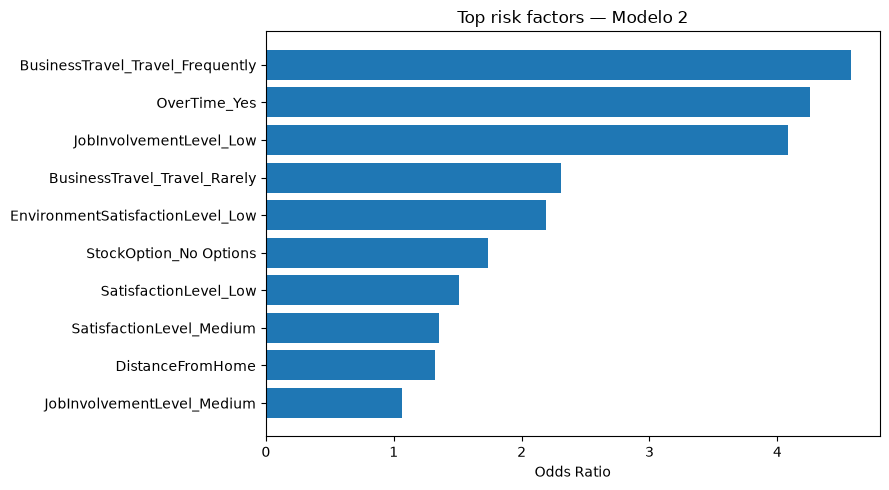

In [180]:
model_2_top_risk_plot = model_2_top_risk.sort_values("Odds_Ratio", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(model_2_top_risk_plot["Feature"], model_2_top_risk_plot["Odds_Ratio"])

plt.xlabel("Odds Ratio")
plt.title("Top risk factors — Modelo 2")
plt.tight_layout()
plt.show()

## 11. Recall-Oriented Alternative

The recall-oriented alternative is:

**Modelo 3 — Faixa Salarial**  
**Estimator:** Logistic Regression Balanced  
**Threshold:** 0.58

This model is useful when the priority is reducing false negatives. It identifies more employees who actually leave, but at the cost of increasing false positives.

This strategy may be appropriate when the cost of a false positive is relatively low, such as when the intervention is a check-in, internal survey, manager follow-up, or non-invasive retention action.

In [181]:
model_3_top_risk = (
    model_3_odds[model_3_odds["Odds_Ratio"]>1]
    .sort_values("Odds_Ratio", ascending=False)
    .reset_index(drop=True)
)

model_3_top_risk

,Feature,Coefficient,Odds_Ratio
0,JobInvolvementLevel_Low,1.487769,4.427208
1,OverTime_Yes,1.425061,4.158110
2,BusinessTravel_Travel_Frequently,1.354520,3.874900
3,IncomeGroup_Low,1.076484,2.934345
4,EnvironmentSatisfactionLevel_Low,0.921126,2.512117
5,BusinessTravel_Travel_Rarely,0.808493,2.244523
6,DistanceGroup_21-30,0.552475,1.737549
7,SatisfactionLevel_Low,0.492775,1.636853
8,DistanceGroup_11-20,0.379846,1.462059
9,SatisfactionLevel_Medium,0.210305,1.234054


In [182]:
model_3_top_protective = (
    model_3_odds[model_3_odds["Odds_Ratio"]<=1]
    .sort_values("Odds_Ratio", ascending=True)
    .reset_index(drop=True)
)

model_3_top_protective

,Feature,Coefficient,Odds_Ratio
0,WorkLifeBalanceLevel_Better,-1.383681,0.250654
1,WorkLifeBalanceLevel_Good,-0.804493,0.447315
2,IncomeGroup_Very High,-0.739501,0.477352
3,WorkLifeBalanceLevel_Best,-0.694429,0.499359
4,SatisfactionLevel_Very High,-0.605673,0.545707
5,EnvironmentSatisfactionLevel_Very High,-0.217316,0.804675
6,JobInvolvementLevel_Very High,-0.205958,0.813867
7,IncomeGroup_Medium,-0.202134,0.816985
8,EnvironmentSatisfactionLevel_Medium,-0.114764,0.891576


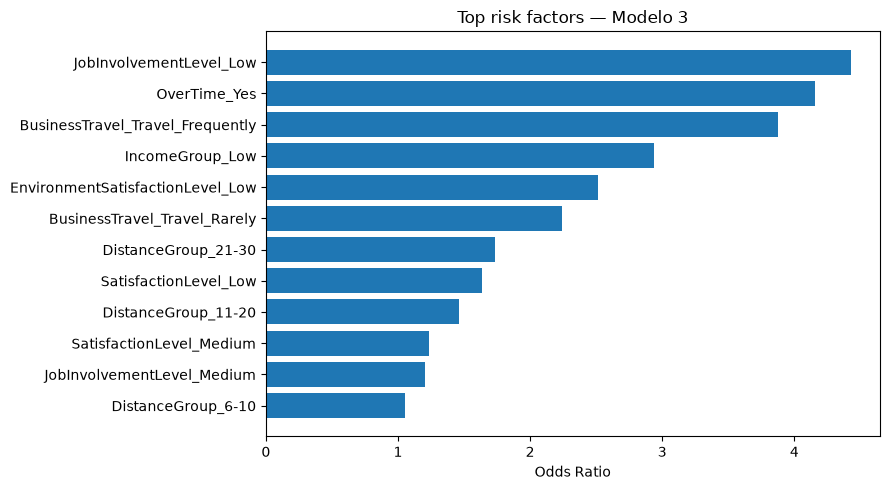

In [183]:
model_3_top_risk_plot = model_3_top_risk.sort_values("Odds_Ratio", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(model_3_top_risk_plot["Feature"], model_3_top_risk_plot["Odds_Ratio"])

plt.xlabel("Odds Ratio")
plt.title("Top risk factors — Modelo 3")
plt.tight_layout()
plt.show()

## 12. Business Implications

The results suggest that employee attrition may be associated with several organizational, job-related, and individual-context dimensions:

* workload and overtime;
* frequent business travel;
* low job involvement;
* low job satisfaction and low environment satisfaction;
* limited access to benefits, such as stock options;
* lower income;
* lower job level;
* poorer work-life balance;
* greater distance from home.

These findings are consistent with the broader turnover literature, which commonly relates employee turnover to job attitudes, organizational context, job demands, perceived rewards, career opportunities, and work-life conditions. However, these factors should be interpreted as associations identified in this dataset rather than as direct causal effects.

From a business perspective, the model may support retention strategies by helping organizations identify groups of employees who appear to be more vulnerable to attrition. In this sense, the model can be useful for guiding workload monitoring, employee engagement initiatives, satisfaction tracking, benefits review, career development, and flexible work policies.

The model should therefore be used as a decision-support tool, not as an automatic decision-making system. Any practical application should include human evaluation, contextual analysis, and ethical consideration.

| Area                      | Model insight                                                                                                                      | Possible action                                                                         |
| ------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------- |
| Workload management       | Overtime and workload-related patterns appear to be associated with higher attrition risk                                          | Monitor excessive overtime, workload concentration, and potential signs of job stress   |
| Business travel           | Frequent business travel may indicate higher job demands and potential work-life disruption                                        | Review travel frequency and provide support for employees who travel often              |
| Employee engagement       | Lower job involvement appears to be associated with higher attrition risk                                                          | Develop engagement initiatives, manager follow-ups, and opportunities for participation |
| Satisfaction monitoring   | Lower job satisfaction and environment satisfaction are associated with higher attrition risk                                      | Use pulse surveys, satisfaction check-ins, and team-level climate monitoring            |
| Benefits and compensation | Limited access to benefits, such as stock options, and lower income appear to be linked to higher risk                             | Review benefit policies, compensation fairness, and reward structures                   |
| Career and job level      | Lower job levels may represent more vulnerable employee groups, possibly due to career stage, income, or progression opportunities | Support onboarding, internal mobility, career development, and progression paths        |
| Commuting distance        | Greater distance from home may reflect contextual or work-life constraints associated with attrition risk                          | Consider flexibility, hybrid-work alternatives, or commuting support where applicable   |
| Work-life balance         | Better work-life balance appears to be associated with lower attrition risk                                                        | Promote policies that support flexibility, workload balance, and employee well-being    |

## 13. Limitations

This analysis has some limitations that should be considered when interpreting the results.

First, the dataset is imbalanced, which makes the identification of attrition cases more challenging. Since employees who leave represent a smaller group, the model may have more difficulty detecting these cases accurately.

Second, several variables are correlated with each other, especially variables related to job level, income, career stage, tenure, and role stability. For this reason, some predictors should not be interpreted in isolation, as they may represent overlapping dimensions of the employee experience.

Third, the results should be interpreted as associations, not causal effects. The model can identify patterns related to attrition, but it cannot prove that a specific factor directly causes employees to leave.

Fourth, some variables are specific to the structure of this dataset. For example, business travel, stock options, and distance from home should be interpreted as contextual indicators rather than universal predictors of turnover.

Fifth, turnover is a complex and context-dependent phenomenon. The relevance of each factor may vary according to industry, role, labour market conditions, organizational culture, and individual circumstances.

Finally, any practical use of this model should include human evaluation and ethical consideration. The model should not be used to make automatic decisions about employees, but rather to support reflection, diagnosis, and preventive retention strategies.

## 14. Final Conclusion

This project shows that logistic regression can provide a useful balance between predictive performance and interpretability in employee attrition analysis.

The results suggest that attrition is associated with a combination of workload-related factors, job attitudes, satisfaction, benefits, compensation, career level, commuting distance, and work-life balance. This supports the idea that employee turnover should be understood as a multidimensional phenomenon rather than as the result of a single isolated factor.

The integrated multidimensional model achieved strong predictive performance, but it was kept only as a control model. It was not selected as the final model because it is more complex and less suitable for business interpretation. In a decision-support context, interpretability is especially relevant because the model outputs need to be understandable and actionable for organizational decision-makers.

Two practical strategies were identified:

1. **Balanced and interpretable strategy**
   Use `Modelo 2 — Nível Hierárquico e Benefícios` with balanced logistic regression and threshold 0.71. This strategy is recommended when the objective is to obtain a stable, explainable, and balanced decision-support tool. It may be more appropriate when the organization wants to combine predictive performance with clearer business interpretation.

2. **Recall-oriented strategy**
   Use `Modelo 3 — Faixa Salarial` with balanced logistic regression and threshold 0.58. This strategy is recommended when the priority is to reduce false negatives and identify more employees who may be at risk of leaving, even if this increases the number of false positives. This approach may be useful in contexts where failing to identify a potential leaver is considered more costly than incorrectly flagging an employee as at risk.

The threshold values were defined based on the empirical performance of the models and the business objective of each strategy. Therefore, they should not be interpreted as general recommendations from the turnover literature, but as decisions derived from the model evaluation process.

Overall, the project suggests that logistic regression can be a suitable approach for employee attrition analysis when the goal is not only prediction, but also interpretation and practical decision support. However, the results should be applied carefully, considering the limitations of the dataset, the organizational context, and the ethical implications of using predictive models in human resources.
